# 5.0 Evaluación de los modelos

Este notebook evalúa los clusters construidos para estudiantes con bajo índice socioeconómico. La pregunta que orienta el análisis es:

> **¿Qué caracteriza a los perfiles de resiliencia académica, es decir, estudiantes con bajo INSE que logran ubicarse en percentiles sobresalientes en Saber Pro?**

Los resultados académicos no participaron en la creación de los clusters. Se utilizan en esta fase para revisar en qué perfiles se concentra la resiliencia.

## 1. Librerías y carga de resultados

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')

if Path('data/processed/saber_pro_2024_clusters_estudiantes.csv').exists():
    project_root = Path.cwd()
else:
    project_root = Path.cwd().parent

results_path = project_root / 'data/processed/saber_pro_2024_clusters_estudiantes.csv'
df = pd.read_csv(results_path, encoding='utf-8-sig', low_memory=False)
print(f'Resultados: {df.shape[0]:,} filas x {df.shape[1]} columnas')
display(df.head())

Resultados: 61,943 filas x 52 columnas


,estu_consecutivo,cluster_kmeans,cluster_dbscan,resiliencia_flag,punt_global,percentil_global,estu_inse_individual,indice_bienes_hogar,fami_estratovivienda,fami_educacionmadre,...,pca_6,pca_7,pca_8,pca_9,pca_10,pca_plot_1,pca_plot_2,dbscan_pca_1,dbscan_pca_2,dbscan_pca_3
0,EK202410034360,0,1.0,False,137,36.0,33.304157,0.0,Estrato 1,Secundaria (Bachillerato) incompleta,...,1.122931,-0.418909,-0.845071,0.590014,0.657792,0.621053,-0.794886,0.499059,-0.787425,0.447165
1,EK202410024455,0,1.0,False,163,75.0,28.782057,2.0,Estrato 1,Primaria completa,...,0.516880,0.329437,-0.002176,1.110854,-0.029651,-0.945664,-0.826714,-0.759907,-0.818954,0.336279
2,EK202410034703,1,NaN,False,151,58.0,41.502777,5.0,Estrato 2,Primaria incompleta,...,1.033143,-0.332245,0.849021,0.476042,0.417635,-1.142688,0.667803,-0.918231,0.661535,-0.009603
3,EK202410019391,1,NaN,False,139,39.0,40.790611,3.0,Estrato 3,Secundaria (Bachillerato) incompleta,...,-0.176556,1.011596,-0.565377,-0.204246,0.070879,-0.688254,2.129669,-0.553060,2.109678,-0.263248
4,EK202410065110,1,0.0,False,157,67.0,38.005848,4.0,Estrato 2,Ninguno,...,-0.225470,-0.886579,0.739948,1.233345,-0.211585,-1.916220,0.674385,-1.539818,0.668055,0.011361


## 2. Verificación de cobertura

K-Means asigna un cluster a toda la población de bajo INSE. DBSCAN se aplicó a una muestra de 30.000 registros, por lo que los valores vacíos en su etiqueta representan estudiantes que no participaron en ese modelo.

In [2]:
required_columns = [
    'cluster_kmeans', 'cluster_dbscan', 'resiliencia_flag',
    'punt_global', 'percentil_global', 'estu_inse_individual',
    'indice_bienes_hogar', 'pca_plot_1', 'pca_plot_2'
]
missing_columns = [column for column in required_columns if column not in df.columns]
assert not missing_columns, f'Faltan columnas: {missing_columns}'
assert df['cluster_kmeans'].notna().all()
assert df['cluster_dbscan'].notna().sum() == 30_000

pca_columns = [column for column in df.columns
               if column.startswith('pca_') and not column.startswith('pca_plot_')]
dbscan_pca_columns = [column for column in df.columns if column.startswith('dbscan_pca_')]
coverage = pd.DataFrame({
    'modelo': ['K-Means', 'DBSCAN'],
    'registros': [df['cluster_kmeans'].notna().sum(), df['cluster_dbscan'].notna().sum()]
})
coverage['porcentaje'] = coverage['registros'] / len(df) * 100
display(coverage.round(2))
print(f'Componentes K-Means: {len(pca_columns)}')
print(f'Componentes DBSCAN: {len(dbscan_pca_columns)}')

,modelo,registros,porcentaje
0,K-Means,61943,100.00
1,DBSCAN,30000,48.43


Componentes K-Means: 10
Componentes DBSCAN: 3


## 3. Calidad interna de K-Means

Silhouette es mejor cuando se acerca a 1, Davies-Bouldin cuando se acerca a 0 y Calinski-Harabasz cuando aumenta al comparar configuraciones sobre los mismos datos. Silhouette se calcula con una muestra de 10.000 registros para reducir el tiempo.

In [3]:
X_kmeans = df[pca_columns].to_numpy(dtype='float32')
kmeans_labels = df['cluster_kmeans'].to_numpy()
kmeans_metrics = pd.DataFrame({
    'métrica': ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz'],
    'resultado': [
        silhouette_score(X_kmeans, kmeans_labels, sample_size=10_000,
                         random_state=RANDOM_STATE),
        davies_bouldin_score(X_kmeans, kmeans_labels),
        calinski_harabasz_score(X_kmeans, kmeans_labels)
    ]
})
display(kmeans_metrics.round(3))

,métrica,resultado
0,Silhouette,0.167
1,Davies-Bouldin,1.719
2,Calinski-Harabasz,11734.545


K-Means obtiene un Silhouette cercano a **0,167** y un Davies-Bouldin cercano a **1,719**. Los clusters tienen una separación limitada y comparten características, por lo que deben interpretarse como perfiles generales y no como categorías rígidas. Calinski-Harabasz se conserva como referencia para futuras comparaciones sobre esta misma matriz.

,cluster,estudiantes,porcentaje
0,0,21541,34.78
1,1,19417,31.35
2,2,5272,8.51
3,3,15713,25.37


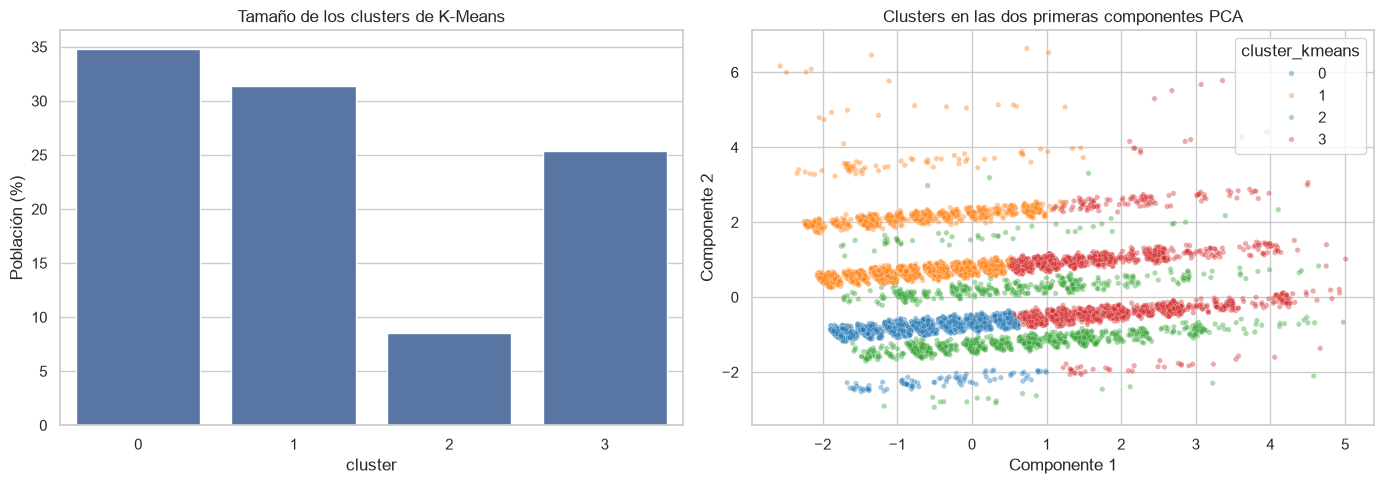

In [4]:
kmeans_sizes = df['cluster_kmeans'].value_counts().sort_index().rename_axis('cluster').reset_index(name='estudiantes')
kmeans_sizes['porcentaje'] = kmeans_sizes['estudiantes'] / len(df) * 100
display(kmeans_sizes.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=kmeans_sizes, x='cluster', y='porcentaje', color='#4C72B0', ax=axes[0])
axes[0].set_title('Tamaño de los clusters de K-Means')
axes[0].set_ylabel('Población (%)')
sample_plot = df.sample(n=min(15_000, len(df)), random_state=RANDOM_STATE)
sns.scatterplot(data=sample_plot, x='pca_plot_1', y='pca_plot_2',
                hue='cluster_kmeans', palette='tab10', s=15, alpha=0.4, ax=axes[1])
axes[1].set_title('Clusters en las dos primeras componentes PCA')
axes[1].set_xlabel('Componente 1')
axes[1].set_ylabel('Componente 2')
plt.tight_layout()
plt.show()

Los cuatro clusters tienen tamaños suficientes para ser analizados. El mayor reúne cerca del 35% y el menor aproximadamente el 9%. La visualización de dos componentes muestra cercanía entre algunos perfiles; el modelo utilizó diez componentes, así que esta gráfica es solamente una representación resumida.

## 4. Perfil de los clusters de K-Means

In [5]:
cluster_profile = df.groupby('cluster_kmeans').agg(
    estudiantes=('cluster_kmeans', 'size'),
    puntaje_promedio=('punt_global', 'mean'),
    percentil_promedio=('percentil_global', 'mean'),
    inse_promedio=('estu_inse_individual', 'mean'),
    bienes_promedio=('indice_bienes_hogar', 'mean'),
    resilientes=('resiliencia_flag', 'sum'),
    tasa_resiliencia=('resiliencia_flag', 'mean')
)
cluster_profile['tasa_resiliencia'] *= 100
cluster_profile['participacion_resilientes'] = (
    cluster_profile['resilientes'] / df['resiliencia_flag'].sum() * 100
)
display(cluster_profile.round(2))

,estudiantes,puntaje_promedio,percentil_promedio,inse_promedio,bienes_promedio,resilientes,tasa_resiliencia,participacion_resilientes
cluster_kmeans,,,,,,,,
0,21541,133.95,35.95,35.73,2.83,508,2.36,23.01
1,19417,138.39,40.96,38.88,3.22,752,3.87,34.06
2,5272,137.65,40.24,37.56,2.73,167,3.17,7.56
3,15713,140.16,43.37,38.93,2.70,781,4.97,35.37


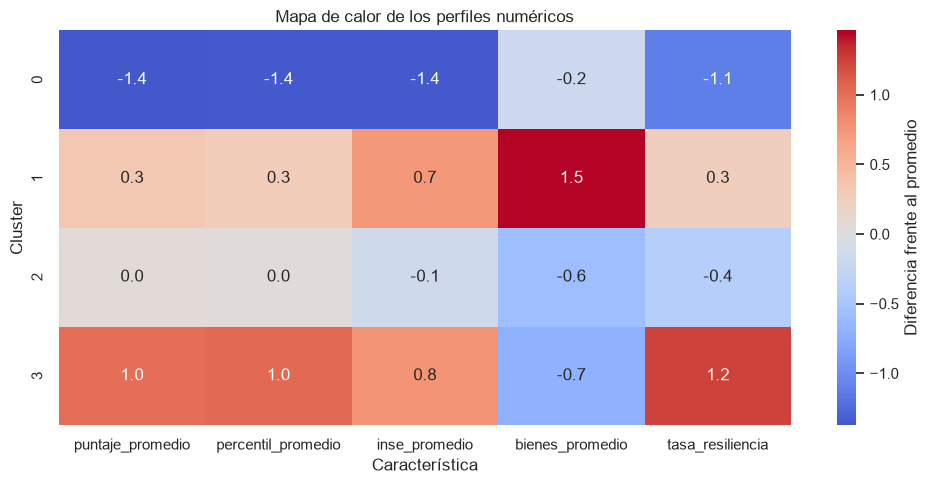

In [6]:
heatmap_columns = [
    'puntaje_promedio', 'percentil_promedio', 'inse_promedio',
    'bienes_promedio', 'tasa_resiliencia'
]
heatmap_data = cluster_profile[heatmap_columns]
heatmap_scaled = (heatmap_data - heatmap_data.mean()) / heatmap_data.std()
plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_scaled, annot=True, fmt='.1f', cmap='coolwarm', center=0,
            cbar_kws={'label': 'Diferencia frente al promedio'})
plt.title('Mapa de calor de los perfiles numéricos')
plt.xlabel('Característica')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

El cluster 3 tiene el mayor puntaje, percentil y tasa de resiliencia. Su promedio de bienes no es el más alto. El cluster 1 posee más bienes y un INSE semejante al cluster 3, pero una tasa de resiliencia menor. El cluster 0 presenta los menores promedios de INSE, puntaje y resiliencia.

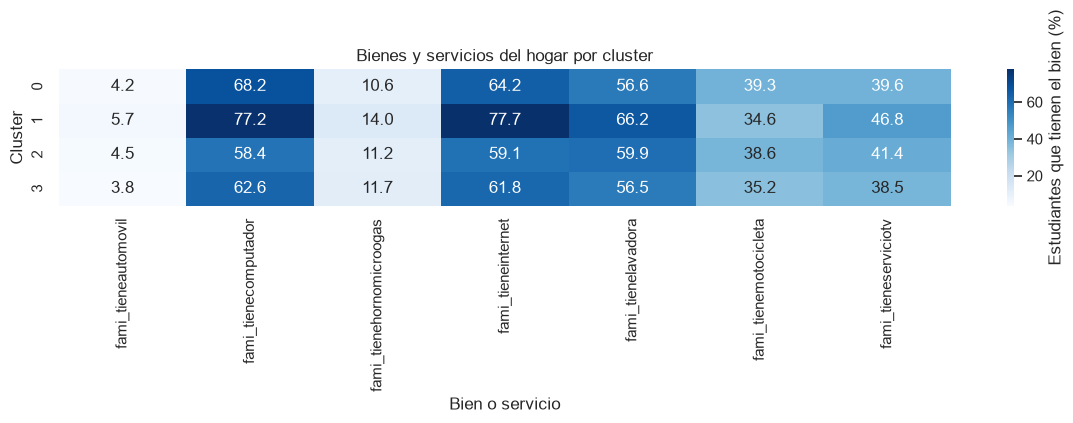

In [7]:
binary_columns = [
    'fami_tieneautomovil', 'fami_tienecomputador', 'fami_tienehornomicroogas',
    'fami_tieneinternet', 'fami_tienelavadora', 'fami_tienemotocicleta',
    'fami_tieneserviciotv'
]
goods_by_cluster = df.groupby('cluster_kmeans')[binary_columns].agg(
    lambda column: column.eq('Si').mean() * 100
)
plt.figure(figsize=(12, 4))
sns.heatmap(goods_by_cluster, annot=True, fmt='.1f', cmap='Blues',
            cbar_kws={'label': 'Estudiantes que tienen el bien (%)'})
plt.title('Bienes y servicios del hogar por cluster')
plt.xlabel('Bien o servicio')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

El cluster 1 tiene las mayores proporciones de computador, internet, lavadora y televisión. El cluster 3 alcanza la mayor resiliencia aunque muestra menos bienes, lo que indica que la diferencia entre estos dos perfiles no depende solamente de los recursos materiales observados.

In [8]:
def cluster_percentages(column):
    return (pd.crosstab(df['cluster_kmeans'], df[column], normalize='index') * 100).round(1)

print('Estrato de vivienda (%)')
display(cluster_percentages('fami_estratovivienda'))
print('Educación de la madre (%)')
display(cluster_percentages('fami_educacionmadre'))
print('Educación del padre (%)')
display(cluster_percentages('fami_educacionpadre'))
print('Actividad de refuerzo genérico (%)')
display(cluster_percentages('estu_actividadrefuerzogeneric'))

Estrato de vivienda (%)


fami_estratovivienda,Estrato 1,Estrato 2,Estrato 3,Estrato 4,Estrato 5,Estrato 6,Sin Estrato
cluster_kmeans,,,,,,,
0,98.2,0.0,0.0,0.0,0.0,0.0,1.8
1,0.0,79.5,18.7,1.3,0.3,0.2,0.0
2,67.5,27.4,3.6,0.2,0.0,0.0,1.2
3,62.3,33.7,2.6,0.3,0.0,0.0,1.0


Educación de la madre (%)


fami_educacionmadre,Educación profesional completa,Educación profesional incompleta,Ninguno,No Aplica,No sabe,Postgrado,Primaria completa,Primaria incompleta,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) incompleta,Técnica o tecnológica completa,Técnica o tecnológica incompleta
cluster_kmeans,,,,,,,,,,,,
0,0.0,0.0,9.3,0.5,0.6,0.0,19.0,42.9,12.0,13.7,1.0,1.0
1,0.1,0.0,7.7,0.5,0.6,0.0,18.8,42.5,13.2,14.7,1.0,0.8
2,3.0,1.0,4.8,0.3,0.3,0.5,12.3,25.7,24.6,13.7,10.4,3.5
3,8.9,2.2,0.2,0.0,0.1,1.5,1.9,1.7,48.6,8.8,20.9,5.2


Educación del padre (%)


fami_educacionpadre,Educación profesional completa,Educación profesional incompleta,Ninguno,No Aplica,No sabe,Postgrado,Primaria completa,Primaria incompleta,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) incompleta,Técnica o tecnológica completa,Técnica o tecnológica incompleta
cluster_kmeans,,,,,,,,,,,,
0,0.0,0.0,12.4,2.0,2.2,0.0,17.6,49.6,5.2,10.6,0.1,0.3
1,0.0,0.0,10.6,2.0,2.4,0.0,17.7,49.1,6.8,10.9,0.2,0.3
2,2.7,0.9,6.3,1.5,1.5,0.2,12.5,30.7,22.1,12.7,6.5,2.4
3,7.4,2.0,0.5,0.3,0.5,1.2,2.7,4.6,49.9,12.1,14.3,4.5


Actividad de refuerzo genérico (%)


estu_actividadrefuerzogeneric,NO INFORMADO - BLOQUE NO DILIGENCIADO,No,Si
cluster_kmeans,,,
0,100.0,0.0,0.0
1,99.9,0.0,0.1
2,0.0,17.5,82.5
3,99.9,0.1,0.1


Los perfiles se pueden resumir así:

- **Cluster 0:** casi todos pertenecen al estrato 1, predomina la educación primaria incompleta de los padres y presenta la menor tasa de resiliencia.
- **Cluster 1:** se concentra en estratos 2 y 3, posee más bienes y alcanza una tasa de resiliencia cercana al promedio.
- **Cluster 2:** reúne principalmente estudiantes que sí tienen información del bloque de preparación y simulacros. Este cluster refleja en gran parte una diferencia de diligenciamiento del cuestionario, por lo que debe interpretarse con precaución.
- **Cluster 3:** combina estratos bajos con niveles educativos de los padres relativamente mayores. Tiene menos bienes que el cluster 1, pero alcanza el mayor desempeño y la mayor tasa de resiliencia.

## 5. Resiliencia académica en K-Means

Estudiantes resilientes: 2,208
Tasa general de resiliencia: 3.56%


,estudiantes,resilientes,tasa_resiliencia,participacion_resilientes,indice_concentracion
cluster_kmeans,,,,,
0,21541,508,2.36,23.01,0.66
1,19417,752,3.87,34.06,1.09
2,5272,167,3.17,7.56,0.89
3,15713,781,4.97,35.37,1.39


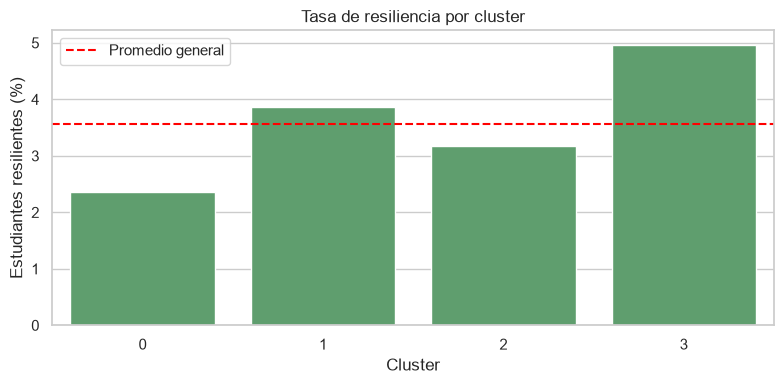

In [9]:
resilient_count = int(df['resiliencia_flag'].sum())
overall_rate = df['resiliencia_flag'].mean() * 100
resilience_by_cluster = cluster_profile[[
    'estudiantes', 'resilientes', 'tasa_resiliencia', 'participacion_resilientes'
]].copy()
resilience_by_cluster['indice_concentracion'] = (
    resilience_by_cluster['tasa_resiliencia'] / overall_rate
)
print(f'Estudiantes resilientes: {resilient_count:,}')
print(f'Tasa general de resiliencia: {overall_rate:.2f}%')
display(resilience_by_cluster.round(2))

plt.figure(figsize=(8, 4))
sns.barplot(data=resilience_by_cluster.reset_index(), x='cluster_kmeans',
            y='tasa_resiliencia', color='#55A868')
plt.axhline(overall_rate, color='red', linestyle='--', label='Promedio general')
plt.title('Tasa de resiliencia por cluster')
plt.xlabel('Cluster')
plt.ylabel('Estudiantes resilientes (%)')
plt.legend()
plt.tight_layout()
plt.show()

Se identifican **2.208 estudiantes resilientes**, equivalentes al **3,56%** de la población con bajo INSE. El cluster 3 presenta una tasa cercana al **4,97%**, aproximadamente 1,4 veces la tasa general, y reúne cerca del 35% de todos los resilientes. El cluster 0 presenta una tasa de 2,36%, claramente inferior al promedio.

### 5.1 Comparación directa entre estudiantes resilientes y no resilientes

In [10]:
df['grupo_resiliencia'] = np.where(
    df['resiliencia_flag'], 'Resiliente', 'Bajo INSE no sobresaliente'
)
numeric_comparison = df.groupby('grupo_resiliencia')[
    ['punt_global', 'percentil_global', 'estu_inse_individual', 'indice_bienes_hogar']
].agg(['mean', 'median'])
display(numeric_comparison.round(2))

def compare_category(column, top=8):
    table = pd.crosstab(df[column], df['grupo_resiliencia'], normalize='columns') * 100
    table['diferencia_pp'] = table['Resiliente'] - table['Bajo INSE no sobresaliente']
    return table.sort_values('diferencia_pp', ascending=False).head(top).round(2)

for column in ['fami_educacionmadre', 'fami_educacionpadre',
               'estu_metodo_prgm', 'inst_caracter_academico', 'inst_origen']:
    print(f'Comparación para: {column}')
    display(compare_category(column))

punt_global        percentil_global         \
                                  mean median             mean median   
grupo_resiliencia                                                       
Bajo INSE no sobresaliente      135.40  136.0            37.76   35.0   
Resiliente                      186.88  184.0            94.03   94.0   

                           estu_inse_individual        indice_bienes_hogar  \
                                           mean median                mean   
grupo_resiliencia                                                            
Bajo INSE no sobresaliente                37.65  38.60                2.91   
Resiliente                                38.68  39.56                2.97   

                                   
                           median  
grupo_resiliencia                  
Bajo INSE no sobresaliente    3.0  
Resiliente                    3.0

Comparación para: fami_educacionmadre


grupo_resiliencia,Bajo INSE no sobresaliente,Resiliente,diferencia_pp
fami_educacionmadre,,,
Secundaria (Bachillerato) completa,22.49,29.80,7.31
Secundaria (Bachillerato) incompleta,12.68,15.81,3.12
Técnica o tecnológica completa,6.74,9.38,2.63
Educación profesional completa,2.45,4.94,2.49
Educación profesional incompleta,0.61,1.63,1.02
No sabe,0.45,0.95,0.50
Postgrado,0.42,0.77,0.35
Técnica o tecnológica incompleta,2.21,2.13,-0.08


Comparación para: fami_educacionpadre


grupo_resiliencia,Bajo INSE no sobresaliente,Resiliente,diferencia_pp
fami_educacionpadre,,,
Secundaria (Bachillerato) completa,18.34,22.37,4.04
Secundaria (Bachillerato) incompleta,11.15,13.99,2.85
Educación profesional completa,2.02,4.62,2.60
Técnica o tecnológica completa,4.23,6.02,1.79
No sabe,1.71,3.26,1.55
No Aplica,1.48,2.26,0.78
Educación profesional incompleta,0.57,1.22,0.66
Postgrado,0.30,0.82,0.52


...

grupo_resiliencia,Bajo INSE no sobresaliente,Resiliente,diferencia_pp
estu_metodo_prgm,,,
PRESENCIAL,64.94,93.93,29.00
SEMI-PRESENCIAL,0.01,0.00,-0.01
DISTANCIA VITUAL,13.05,2.99,-10.06
DISTANCIA,22.01,3.08,-18.93


Comparación para: inst_caracter_academico


grupo_resiliencia,Bajo INSE no sobresaliente,Resiliente,diferencia_pp
inst_caracter_academico,,,
UNIVERSIDAD,57.36,89.99,32.63
TÉCNICA PROFESIONAL,3.23,0.36,-2.87
INSTITUCIÓN TECNOLÓGICA,5.14,0.59,-4.55
INSTITUCIÓN UNIVERSITARIA,34.27,9.06,-25.22


Comparación para: inst_origen


grupo_resiliencia,Bajo INSE no sobresaliente,Resiliente,diferencia_pp
inst_origen,,,
OFICIAL DEPARTAMENTAL,26.14,37.09,10.95
OFICIAL NACIONAL,28.24,31.20,2.97
OFICIAL MUNICIPAL,3.09,4.35,1.26
REGIMEN ESPECIAL,0.04,0.00,-0.04
NO OFICIAL - FUNDACIÓN,19.99,13.99,-6.00
NO OFICIAL - CORPORACIÓN,22.50,13.36,-9.14


La cantidad de bienes es muy semejante entre resilientes y no resilientes. En cambio, entre los resilientes aparecen con mayor frecuencia padres con bachillerato completo o educación superior, programas presenciales, universidades e instituciones oficiales. Estas diferencias son asociaciones y no demuestran causalidad.

## 6. Calidad interna y perfiles de DBSCAN

In [11]:
dbscan_sample = df[df['cluster_dbscan'].notna()].copy()
dbscan_grouped = dbscan_sample[dbscan_sample['cluster_dbscan'] != -1].copy()
X_dbscan = dbscan_grouped[dbscan_pca_columns].to_numpy(dtype='float32')
dbscan_labels = dbscan_grouped['cluster_dbscan'].astype(int).to_numpy()
dbscan_metrics = pd.DataFrame({
    'métrica': ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz'],
    'resultado': [
        silhouette_score(X_dbscan, dbscan_labels, sample_size=10_000,
                         random_state=RANDOM_STATE),
        davies_bouldin_score(X_dbscan, dbscan_labels),
        calinski_harabasz_score(X_dbscan, dbscan_labels)
    ]
})
display(dbscan_metrics.round(3))

dbscan_profile = dbscan_sample.groupby('cluster_dbscan').agg(
    estudiantes=('cluster_dbscan', 'size'),
    resilientes=('resiliencia_flag', 'sum'),
    tasa_resiliencia=('resiliencia_flag', 'mean'),
    bienes_promedio=('indice_bienes_hogar', 'mean'),
    puntaje_promedio=('punt_global', 'mean')
)
dbscan_profile['tasa_resiliencia'] *= 100
display(dbscan_profile.round(2))

,métrica,resultado
0,Silhouette,0.423
1,Davies-Bouldin,0.709
2,Calinski-Harabasz,9593.252


,estudiantes,resilientes,tasa_resiliencia,bienes_promedio,puntaje_promedio
cluster_dbscan,,,,,
-1.0,2088,93,4.45,2.72,138.73
0.0,9955,406,4.08,3.07,139.22
1.0,14803,437,2.95,2.80,135.45
2.0,1796,75,4.18,3.28,138.66
3.0,96,11,11.46,2.52,141.98
4.0,1161,35,3.01,2.71,137.43
5.0,101,2,1.98,3.27,134.74


Clusters encontrados: 6
Ruido: 6.96%
Cluster mayor entre puntos agrupados: 53.03%


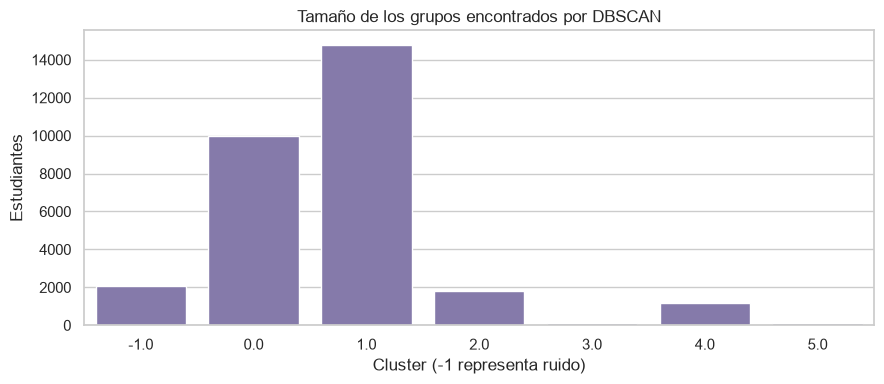

In [12]:
dbscan_noise = (dbscan_sample['cluster_dbscan'] == -1).mean() * 100
dbscan_largest = (
    dbscan_grouped['cluster_dbscan'].value_counts(normalize=True).max() * 100
)
print(f'Clusters encontrados: {dbscan_grouped["cluster_dbscan"].nunique()}')
print(f'Ruido: {dbscan_noise:.2f}%')
print(f'Cluster mayor entre puntos agrupados: {dbscan_largest:.2f}%')

plt.figure(figsize=(9, 4))
sns.barplot(data=dbscan_profile.reset_index(), x='cluster_dbscan',
            y='estudiantes', color='#8172B2')
plt.title('Tamaño de los grupos encontrados por DBSCAN')
plt.xlabel('Cluster (-1 representa ruido)')
plt.ylabel('Estudiantes')
plt.tight_layout()
plt.show()

DBSCAN obtiene un Silhouette cercano a **0,423** y Davies-Bouldin cercano a **0,709**. Encuentra 6 clusters y marca aproximadamente el 6,96% de la muestra como ruido. Los clusters 0, 1 y 2 contienen la mayor parte de los registros. El cluster 3 alcanza una tasa de resiliencia elevada, pero solo tiene 96 estudiantes; por su tamaño no es suficiente para generalizar. Los puntos de ruido también incluyen estudiantes resilientes, pero ser ruido significa tener un perfil contextual poco común, no poseer necesariamente resiliencia.

## 7. Respuesta a la pregunta de negocio

El perfil que presenta la mayor concentración de resiliencia combina **bajo INSE y pocos bienes materiales con un nivel educativo de los padres relativamente mayor**, especialmente bachillerato completo, formación técnica o educación profesional. Esto se observa con claridad en el cluster 3 de K-Means.

La resiliencia también aparece con mayor frecuencia en estudiantes de programas presenciales, universidades e instituciones oficiales. Estas condiciones pueden representar contextos educativos favorables, pero el dataset no permite demostrar que sean la causa del resultado sobresaliente.

No todos los estudiantes con condiciones semejantes son resilientes y los casos se distribuyen en todos los clusters. Por lo tanto, la resiliencia académica no corresponde a un grupo totalmente separado, sino a una concentración mayor dentro de ciertos perfiles familiares y educativos.

## 8. Conclusiones y limitaciones

1. Se identificaron 2.208 estudiantes resilientes, equivalentes al 3,56% de la población con bajo INSE.
2. El cluster 3 de K-Means es el perfil más relacionado con resiliencia: su tasa es 4,97% y reúne aproximadamente el 35% de los casos.
3. La educación de los padres diferencia mejor este perfil que la cantidad de bienes del hogar.
4. El cluster 0 representa el contexto de mayor desventaja observada y presenta la menor tasa de resiliencia.
5. El cluster 2 está influido por la disponibilidad del bloque de preguntas de preparación; no se debe interpretar automáticamente como mayor apoyo académico.
6. K-Means ofrece perfiles amplios y cubre toda la población estudiada. DBSCAN complementa el análisis identificando estructuras densas y casos poco comunes sobre una muestra.
7. La separación limitada de K-Means indica que las fronteras entre perfiles no son rígidas.
8. Los resultados son descriptivos: no permiten establecer causas ni afirmar que pertenecer a un cluster produzca un mejor resultado.